In [1]:
import scipy
import numpy as np
import scipy.interpolate as si
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Introduction to numerical algorithms
## Practice class 8 - Fitting and error propagation

Some of the examples and exercises were inspired by 
- Primer on Programming in Python and Mathematical/Computational Techniques for Scientists and Engineers, Department of Earth Science and Engineering, Imperial College London Lecture series
- Special Projects in Astronomy: Astronomy Research Techniques, lecture held by Sean Griffin and Amy Lien
- Python tutorial series by Luke Polson

Real-world data often reveals patterns, and scientists use Python to help make predictions based on these observations. However, human judgment is still key in assessing the sensibility of predictions.

Consider a dataset of global temperature changes over the years. Each year (x-axis) has a corresponding temperature (y-axis). With \( N+1 \) data points, each point \( i \) has an \( x \) value (year) and a \( y \) value (temperature), ranging from \( i=0 \) to \( N \).

Our dataset can be represented as:

$$ \text{Dataset} = \{ (x_0, y_0), (x_1, y_1), \ldots, (x_N, y_N) \} $$

or simply:

$$ (x_i, y_i), \quad i=0, \ldots, N. $$

## Interpolation vs. Curve Fitting

Although often used interchangeably, interpolation and curve fitting serve different purposes. Both assume some relationship between \( x \) and \( y \) (and possibly more dimensions) and aim to approximate this function using limited data points.

In our temperature example, we seek to understand if there’s a pattern between temperature and year, such as whether temperature has consistently increased. If data is missing for some years, we might use the established relationship to estimate these values.

> ### Curve Fitting vs. Interpolation
>
> - **Interpolation**: Finds a function that *passes through all data points*, often used when data is assumed error-free and there’s a clear \( x \)-to-\( y \) mapping.
> - **Curve Fitting**: Finds the best-fit function *without needing to go through all data points*, suitable for data with error bars or ambiguous mappings.

While interpolation may seem preferable as it goes through all data points, real-world data often has measurement errors, making curve fitting more robust to small changes in data.

The term "interpolation" reflects its use in predicting values within the range of given data points. For instance, with temperatures recorded every 5 years from 1990 to 2020, interpolation allows us to estimate temperatures for years within this range.

This notebook will explore interpolation and curve fitting using NumPy and SciPy libraries.

### Mathematical Expression

Interpolation finds a function that maps each \( x \) value in the dataset to a corresponding \( y \) value:

$$ y_i = f(x_i), \quad \forall i $$

where \( f \) is the [interpolant](http://mathworld.wolfram.com/Interpolant.html). Predictions can only be made within the range of given \( x \) values:

$$ \min(x_i) < x < \max(x_i) $$

with a constraint on distinct \( x \)-values:

$$ x_0 < x_1 < \dots < x_N $$

### Simple Example: Linear Interpolation

Linear interpolation joins data points with straight lines, creating a piecewise function. Given:

$$ \text{Dataset} = \{ (0.5, 0.5), (2.0, 0.4), (4.0, 0.3), (5.0, 0.1), (7.0, 0.9), (9.0, 0.8) \} $$

Using the first two points, we find the line equation \( y = mx + c \) with:

$$ m = \frac{y_2 - y_1}{x_2 - x_1}, \quad c = y_1 - mx_1 $$

For points \((0.5, 0.5)\) and \((2.0, 0.4)\), we get:

$$ f(x) = -\frac{1}{15}x + \frac{8}{15}, \quad 0.5 < x < 2.0 $$

Repeating for each pair, we construct a piecewise linear function:

$$
f(x) =
\begin{cases}
-\frac{1}{15}x + \frac{8}{15}, & 0.5 < x < 2.0 \\
-\frac{1}{20}x + \frac{1}{2}, & 2.0 < x < 4.0 \\
\quad \quad \cdots
\end{cases}
$$

You can code this process to compute \( m \) and \( c \) for each segment.

## Task 1 

Write a simple function that calculates the coefficients of piece-wise linear interpolation. 
1. Do it manually following the formulas above
2. How would you visualize it in python the simplest possible way? Do it!

Piecewise linear interpolation can be easily done in Python. First, let's begin with plotting the points on their own. Python will automatically join the points together with lines unless otherwise specified. The `"o"` was used in the `plt.plot()` to ensure that bullets were shown instead of lines.

Now, let's plot the piecewise linear function. We will use the function from above, so be sure to run the cell above so that the function is loaded.

## Polynomial Interpolation

Given \( N+1 \) data points $ (x_i, y_i) $, polynomial interpolation finds a degree \( N \) polynomial:

$$ P_N(x) = a_0 + a_1 x + a_2 x^2 + \ldots + a_N x^N $$

where $( a_0, \, a_1, \, \ldots, \, a_N )$ are coefficients. Since there are \( N+1 \) coefficients, they can be uniquely determined from the \( N+1 \) data points by solving a square matrix system.

### Lagrange Polynomial

An alternative to solving a matrix system is using the [Lagrange polynomial](https://mathworld.wolfram.com/LagrangeInterpolatingPolynomial.html), which constructs the interpolant as:

$$ L(x) = \sum_{i=0}^{N} y_i \ell_i(x) $$

where $ \ell_i(x) $ are Lagrange basis polynomials, and the $ y_i $ values directly act as weights. This method avoids matrix inversion, as weights are known from data.

Each basis polynomial $\ell_i(x)$ is defined by:

$$ \ell_i(x) := \prod_{0 \le m \le N, m \neq i} \frac{x - x_m}{x_i - x_m} $$

This structure ensures that $\ell_j(x_i) = 0$ for $j \neq i$ and $\ell_i(x_i) = 1$, allowing $L(x)$ to exactly interpolate the data points.

Using `scipy.interpolate.lagrange`, we can compute the Lagrange polynomial for a given dataset.

## Task 2

Using `scipy.interpolate.lagrange`, interpolate the previous datapoints!

### Error in Lagrange interpolation

Note that it can be proven that in the case where we are interpolating a known function (e.g. a complicated non-polynomial function such as $\exp$ or $\sin$) by a simpler polynomial, the error at any point we evaluate the interpolant at is proportional to:

- the distance of that point from any of the data points (which makes sense as the error is obviously zero at the data points),
- and to the $(N+1)$-th derivative of that function evaluated at some location within the bounds of the data, i.e. the more complicated (sharply varying) the function is, the higher the error could be.

This result is sometimes called the [Lagrange remainder theorem](https://en.wikipedia.org/wiki/Polynomial_interpolation#Interpolation_error).


## Task 3

We will sample the function $y(x)=x^3$ at the points $x=(1,2,3)$ and construct Lagrange polynomials - $L_0$ (the constant interpolant going through the $x=2$ data point only), $L_1$ (the linear interpolant going through the $x=1$ and $x=3$ points) and $L_2$ (the quadratic interpolant going through all three points).

## Newton Polynomial
--- 
We will just showcase this

---

The Newton polynomial (or [Newton's divided difference interpolation polynomial](https://mathworld.wolfram.com/NewtonsDividedDifferenceInterpolationFormula.html)) produces the same polynomial as the Lagrange method but is often easier to implement.

A degree $ N $ Newton polynomial is structured as:

$$ P_N(x) = a_0 + (x - x_0)a_1 + (x - x_0)(x - x_1)a_2 + \cdots + (x - x_0)(x - x_1) \cdots (x - x_{N-1})a_N $$

where $ a_0, a_1, \ldots, a_N $ are coefficients derived from the data points.

### Recursive Structure

For example, with $ N = 3 $:

$$ P_3(x) = a_0 + (x - x_0)[a_1 + (x - x_1)[a_2 + (x - x_2)a_3]] $$

This allows us to solve for $ a_0, a_1, \ldots $ using recursive substitution.

1. Substitute $ x = x_0 $ to find $ a_0 = y_0 $.
2. Substitute $ x = x_1 $ to find $ a_1 = \frac{y_1 - y_0}{x_1 - x_0} $.
3. Continue this process to solve for each coefficient.

### Divided Differences

This process is generalized with divided differences:

$$
\Delta y_i = \frac{y_i - y_0}{x_i - x_0}, \quad \Delta^2 y_i = \frac{\Delta y_i - \Delta y_1}{x_i - x_1}, \quad \ldots, \quad \Delta^N y_N = \frac{\Delta^{N-1} y_N - \Delta^{N-1} y_{N-1}}{x_N - x_{N-1}}
$$

The coefficients are:

$$ a_0 = y_0, \quad a_1 = \Delta y_1, \quad a_2 = \Delta^2 y_2, \quad \ldots, \quad a_N = \Delta^N y_N $$

This recursive approach simplifies the calculation of the Newton polynomial coefficients, which can be implemented in code.

Interpolating the same datapoints with Newton interpolation:

In [8]:
# Consider the above example data again
xi = np.array([0.5, 2.0, 4.0, 5.0, 7.0, 9.0])
yi = np.array([0.5, 0.4, 0.3, 0.1, 0.9, 0.8])


def calculate_newton_poly_coeffs(xi, yi):
    """ Evaluate the coefficients a_i recursively using Newton's method
    """
    # Initialise the array 'a' with yi, but take a copy to ensure we don't
    # overwrite our yi data!
    a = yi.copy()

    # We have N+1 data points, and so
    N = len(a) - 1

    # for each k, we compute Δ^k y_i from the a_i = Δ^(k-1) y_i of the previous iteration:
    for k in range(1, N+1):
        # but only for i>=k
        for i in range(k, N+1):
            a[i] = (a[i] - a[k-1])/(xi[i]-xi[k-1])

    return a

def plot_raw_data(x, y, ax):
    """plot x vs y on axes ax, 
    add axes labels and turn on grid
    """
    ax.plot(x, y, 'ko', label='raw data')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.grid(True)

def eval_newton_poly(a, xi, x):
    """ Function to evaluate the Newton polynomial
    at x, given the data point xi and the polynomial coeffs a
    """
    N = len(xi) - 1  # polynomial degree

    P = a[N]
    for k in range(1, N+1):
        P = a[N-k] + (x - xi[N-k])*P
    return P

And now plotting the result:

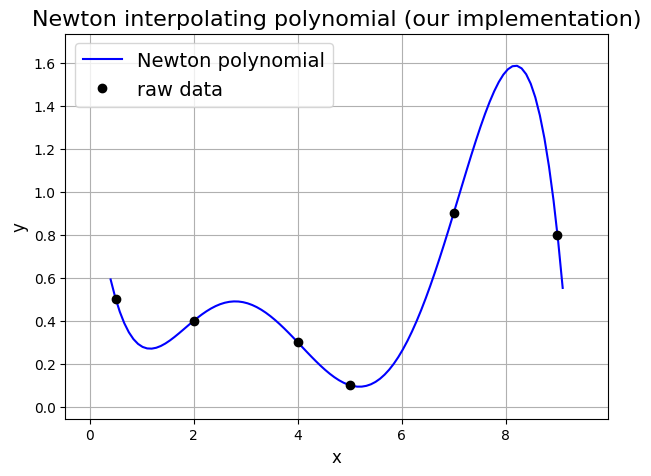

In [9]:
# set up figure
fig = plt.figure(figsize=(7, 5))
ax1 = fig.add_subplot(111)

# add a small margin 
ax1.margins(0.1)

# Evaluate the coefficients of the Newton polynomial
a = calculate_newton_poly_coeffs(xi, yi)
# Evaluate the polynomial at high resolution and plot
x = np.linspace(0.4, 9.1, 100)
ax1.plot(x, eval_newton_poly(a, xi, x), 'b', label='Newton polynomial')

# Overlay raw data
plot_raw_data(xi, yi, ax1)
ax1.set_title('Newton interpolating polynomial (our implementation)', fontsize=16)

# Add a legend
ax1.legend(loc='best', fontsize=14)

plt.show()

## Curve Fitting

[Curve fitting](https://en.wikipedia.org/wiki/Curve_fitting) aims to find a function that approximates the data without necessarily passing through every point, allowing for flexibility with real-world data that contains noise and variability. Unlike interpolation, curve fitting does not require an ordered set of points.

This is common in real data, where fitting a function can smooth out complex or noisy patterns.

### Polynomial Curve Fitting

A polynomial function is often used to create such curves:

- **1st degree** (linear): \( y = mx + c \)
- **2nd degree** (one bend): \( y = ax^2 + bx + c \)
- **3rd degree** (two bends): \( y = ax^3 + bx^2 + cx + d \)

In general, an \( n \)-degree polynomial has \( n-1 \) bends, making it versatile for modeling data with varying complexity.

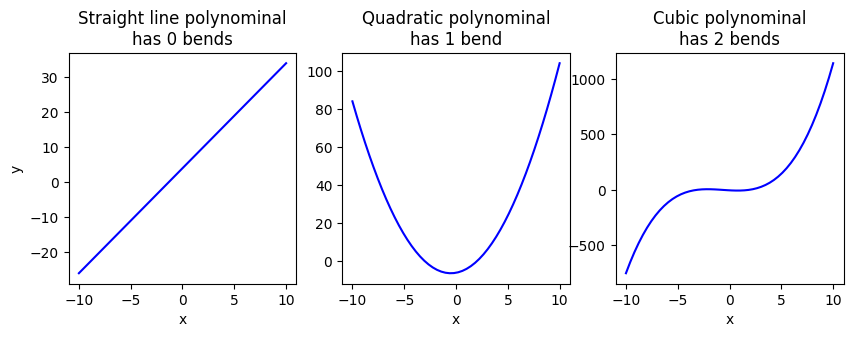

In [2]:
# A snippet to showing polynominal degree and number of bends

def poly_plot(xmin, xmax, number_of_points, a, b, c, d, ax):
    xi = np.linspace(xmin, xmax)
    yi = a*xi**3 + b*xi**2 + c*xi + d
    ax.plot(xi, yi, color="blue")
    ax.set_xlabel("x")
    
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
ax1 = axes[0] 
ax2 = axes[1]
ax3 = axes[2]

poly_plot(-10, 10, 100, 0, 0, 3, 4, ax1)
ax1.set_title("Straight line polynominal\nhas 0 bends")

poly_plot(-10, 10, 100, 0, 1, 1, -6, ax2)
ax2.set_title("Quadratic polynominal\nhas 1 bend")

poly_plot(-10, 10, 100, 1, 2, -5, -6, ax3)
ax3.set_title("Cubic polynominal\nhas 2 bends")

ax1.set_ylabel("y")

plt.show()

## Task 4

Write a code that fits the same initial data `xi` and `yi` with a polynime of abritrary `degree`. Fit the points with polynomyals of degree 0,1,2,3 and plot the results!

### Squared error calculation

As described in the docs ([`numpy.polyfit`](http://docs.scipy.org/doc/numpy/reference/generated/numpy.polyfit.html)), least squares fitting minimises the sum of the squares of the differences between the data provided and the polynomial approximation, i.e. it minimises the expression

$$E = \sum_{i=0}^{N} (P(x_i) - y_i)^2,$$

where $P(x_i)$ is the value of the polynomial function that has been fit to the data evaluated at point $x_i$, and $y_i$ is the $i^{th}$ data value.

<p style="text-align:center;"><img src="https://upload.wikimedia.org/wikipedia/commons/b/b0/Linear_least_squares_example2.svg" width="300px"></p>

Source: [Wikipedia](https://en.wikipedia.org/wiki/Linear_least_squares)


# Task 5
Write a function that evualuates the squared error and use it to evaluate error for each of the polynomial interpolations calculated above.

## What about more complex models and functions?

We can use `scipy.curve_fit()` to fit data! [Docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)

Let's engineer some data with random noise:

In [3]:
def gauss(x, *args):

    A, mu, sigma = args
    return A*np.exp(-(x-mu)**2/(2.*sigma**2)) 

noise_width = 10

n_points = 64​

time_axis = np.linspace(0,16,n_points,endpoint=False)
fine_time_axis = np.linspace(time_axis[0], time_axis[-1], 10 * n_points, endpoint=False)

amplitude = 120
mean = 6.5
width = 0.7

noise = np.random.normal(0, noise_width, len(time_axis))
pedestal = -30
source = -1 * gauss(time_axis, amplitude, mean, width)

contaminated_pulse = source + noise + pedestal
errors = np.ones(len(contaminated_pulse)) * 10

for i in contaminated_pulse:
    if i > 0:
        i = -1 #setting to -1 and not to zero so as to not break some math later.
#this line basically just checks that all of our data points are negative 
#it's basically saying "our electronics can only measure signals in one direction"


## Task 6

Plot the data and fit it with `scipy,curve_fit()`! Plot the fit and the error of the fit! You should put the error on a separate figure! Is this a good fit?

Well this  won't be a good fit! How could we improve this? If we could select more precisely the interval where we expect the signal or if we know the part of the data that truly contains the function/model we want to fit, then we might save the day! Also note that our Gaussian is not exactly zero centered and has an offset! This will be one of your Homeworks!

# Homework 
## Task 1: Improving curve_fit()

Rewrite your model function such that it takes into account the non-zero centering and the offset of the Gaussian, then choose suitable initial parameters and try to fit your function. These initial parameters can be guessed for example by simply plotting the data and taking a look at the plot. Visualize the improved results! Now the curve should fit more exactly the signal! 

## Task 2: Fitting Covid data

We have seen that more complicated functions or models can be fitted to data points with `scipy`'s `curve_fit()` function. In this task you will be asked to:

1. Implement 4 models:

- linear 
- polynomial of 4th degree
- [power-law](https://en.wikipedia.org/wiki/Power_law)
  - $$b \cdot x^a + c$$
- [sigmoid function](https://en.wikipedia.org/wiki/Sigmoid_function)
  - $$\frac{c}{1 + e^{-b(x - a)}} + d$$
- exponential
  - $$a \cdot e^{-b \cdot x} + c$$

2. Read with pandas from the data files. The data is in the attached .zip. The data is from [this GitHub repo](https://github.com/CSSEGISandData/COVID-19).

```
data=pd.read_csv("./archive/covid_19_data.csv")
data=data.drop('Last Update', axis=1)
data=data.drop("SNo",axis=1)
data=data.rename(columns={"ObservationDate": "date", "Country/Region": "country", "Province/State": "state","Confirmed":"confirm","Deaths": "death","Recovered":"recover"})
data.head()
```

3. Filter the data wrt. the following countries: Iran, Italy, South Korea, US, UK
4. Fit the models for the above countries based on several days (use around 60 days)
5. Extrapolate for the next day.
6. Plot the fits and the raw data.



**THE DATA YOU WANT TO FIT IS THE COLUMN NAMED: confirm, which stands for confirmed cases**

**Bonus:** Play a similar game for the other columns and try different functions too! Look up what suitable other models and functions are or were used in epidemic modelling. You can search specifically for COVID19. Reference them! You won't get extra points if you only use the implemented functions. Play with `max_fev` parameter, try error optimization!